<a href="https://colab.research.google.com/github/DeepaJain29/poly_multi_Linear_Reg/blob/main/poly_multi_Linear_Reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 1**


1. (Admission predict Dataset)
Using the supplied predictive variables (GRE score, TOEFL score, University Rating,
etc.) in
the given dataset and predict the admission chance of a new candidate using Linear
Regression.
1. Divide the data into the train-test split of 80:20.
2. Implement the Linear Regression Model to Predict the chances of admission.
3. Implement the Gradient Descent with SSE to Optimize the model for up to 100
iterations and predict the test set.
4. Print the Coefficients of the Optimized model.
5. Print the SSE, MSE, and R2 scores for the Train and Test Sets.


Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Load and Explore the Data

     Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
391         392        318          106                  3  2.0  3.0  8.65   
116         117        299          102                  3  4.0  3.5  8.62   
93           94        301           97                  2  3.0  3.0  7.88   
151         152        332          116                  5  5.0  5.0  9.28   
102         103        314          106                  2  4.0  3.5  8.25   

     Research  Chance of Admit  
391         0             0.71  
116         0             0.56  
93          1             0.44  
151         1             0.94  
102         0             0.62  
Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')
       Serial No.   GRE Score  TOEFL Score  University Rating         SOP  \
count  500.000000  500.000000   500.000000         500.000000  500.000000   
mean   250.500000  316.472

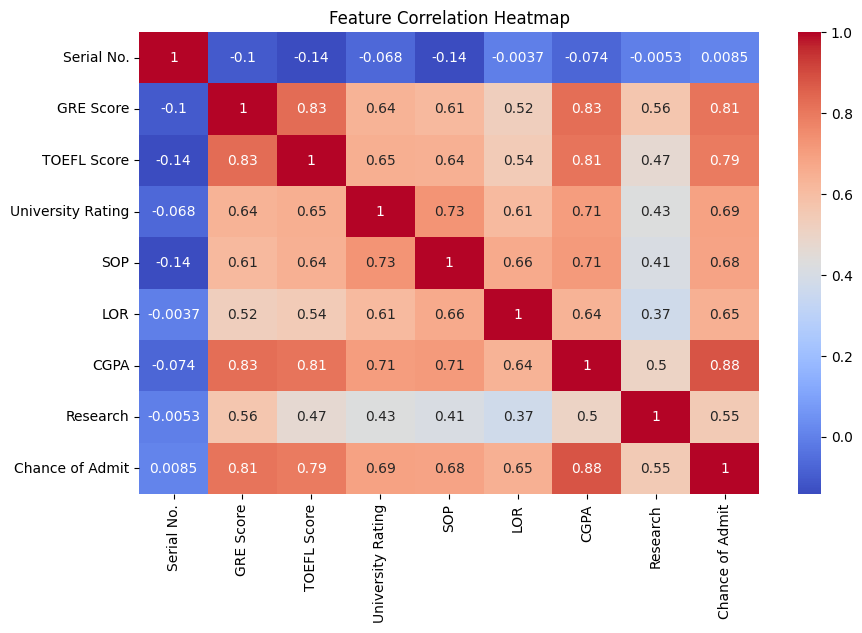

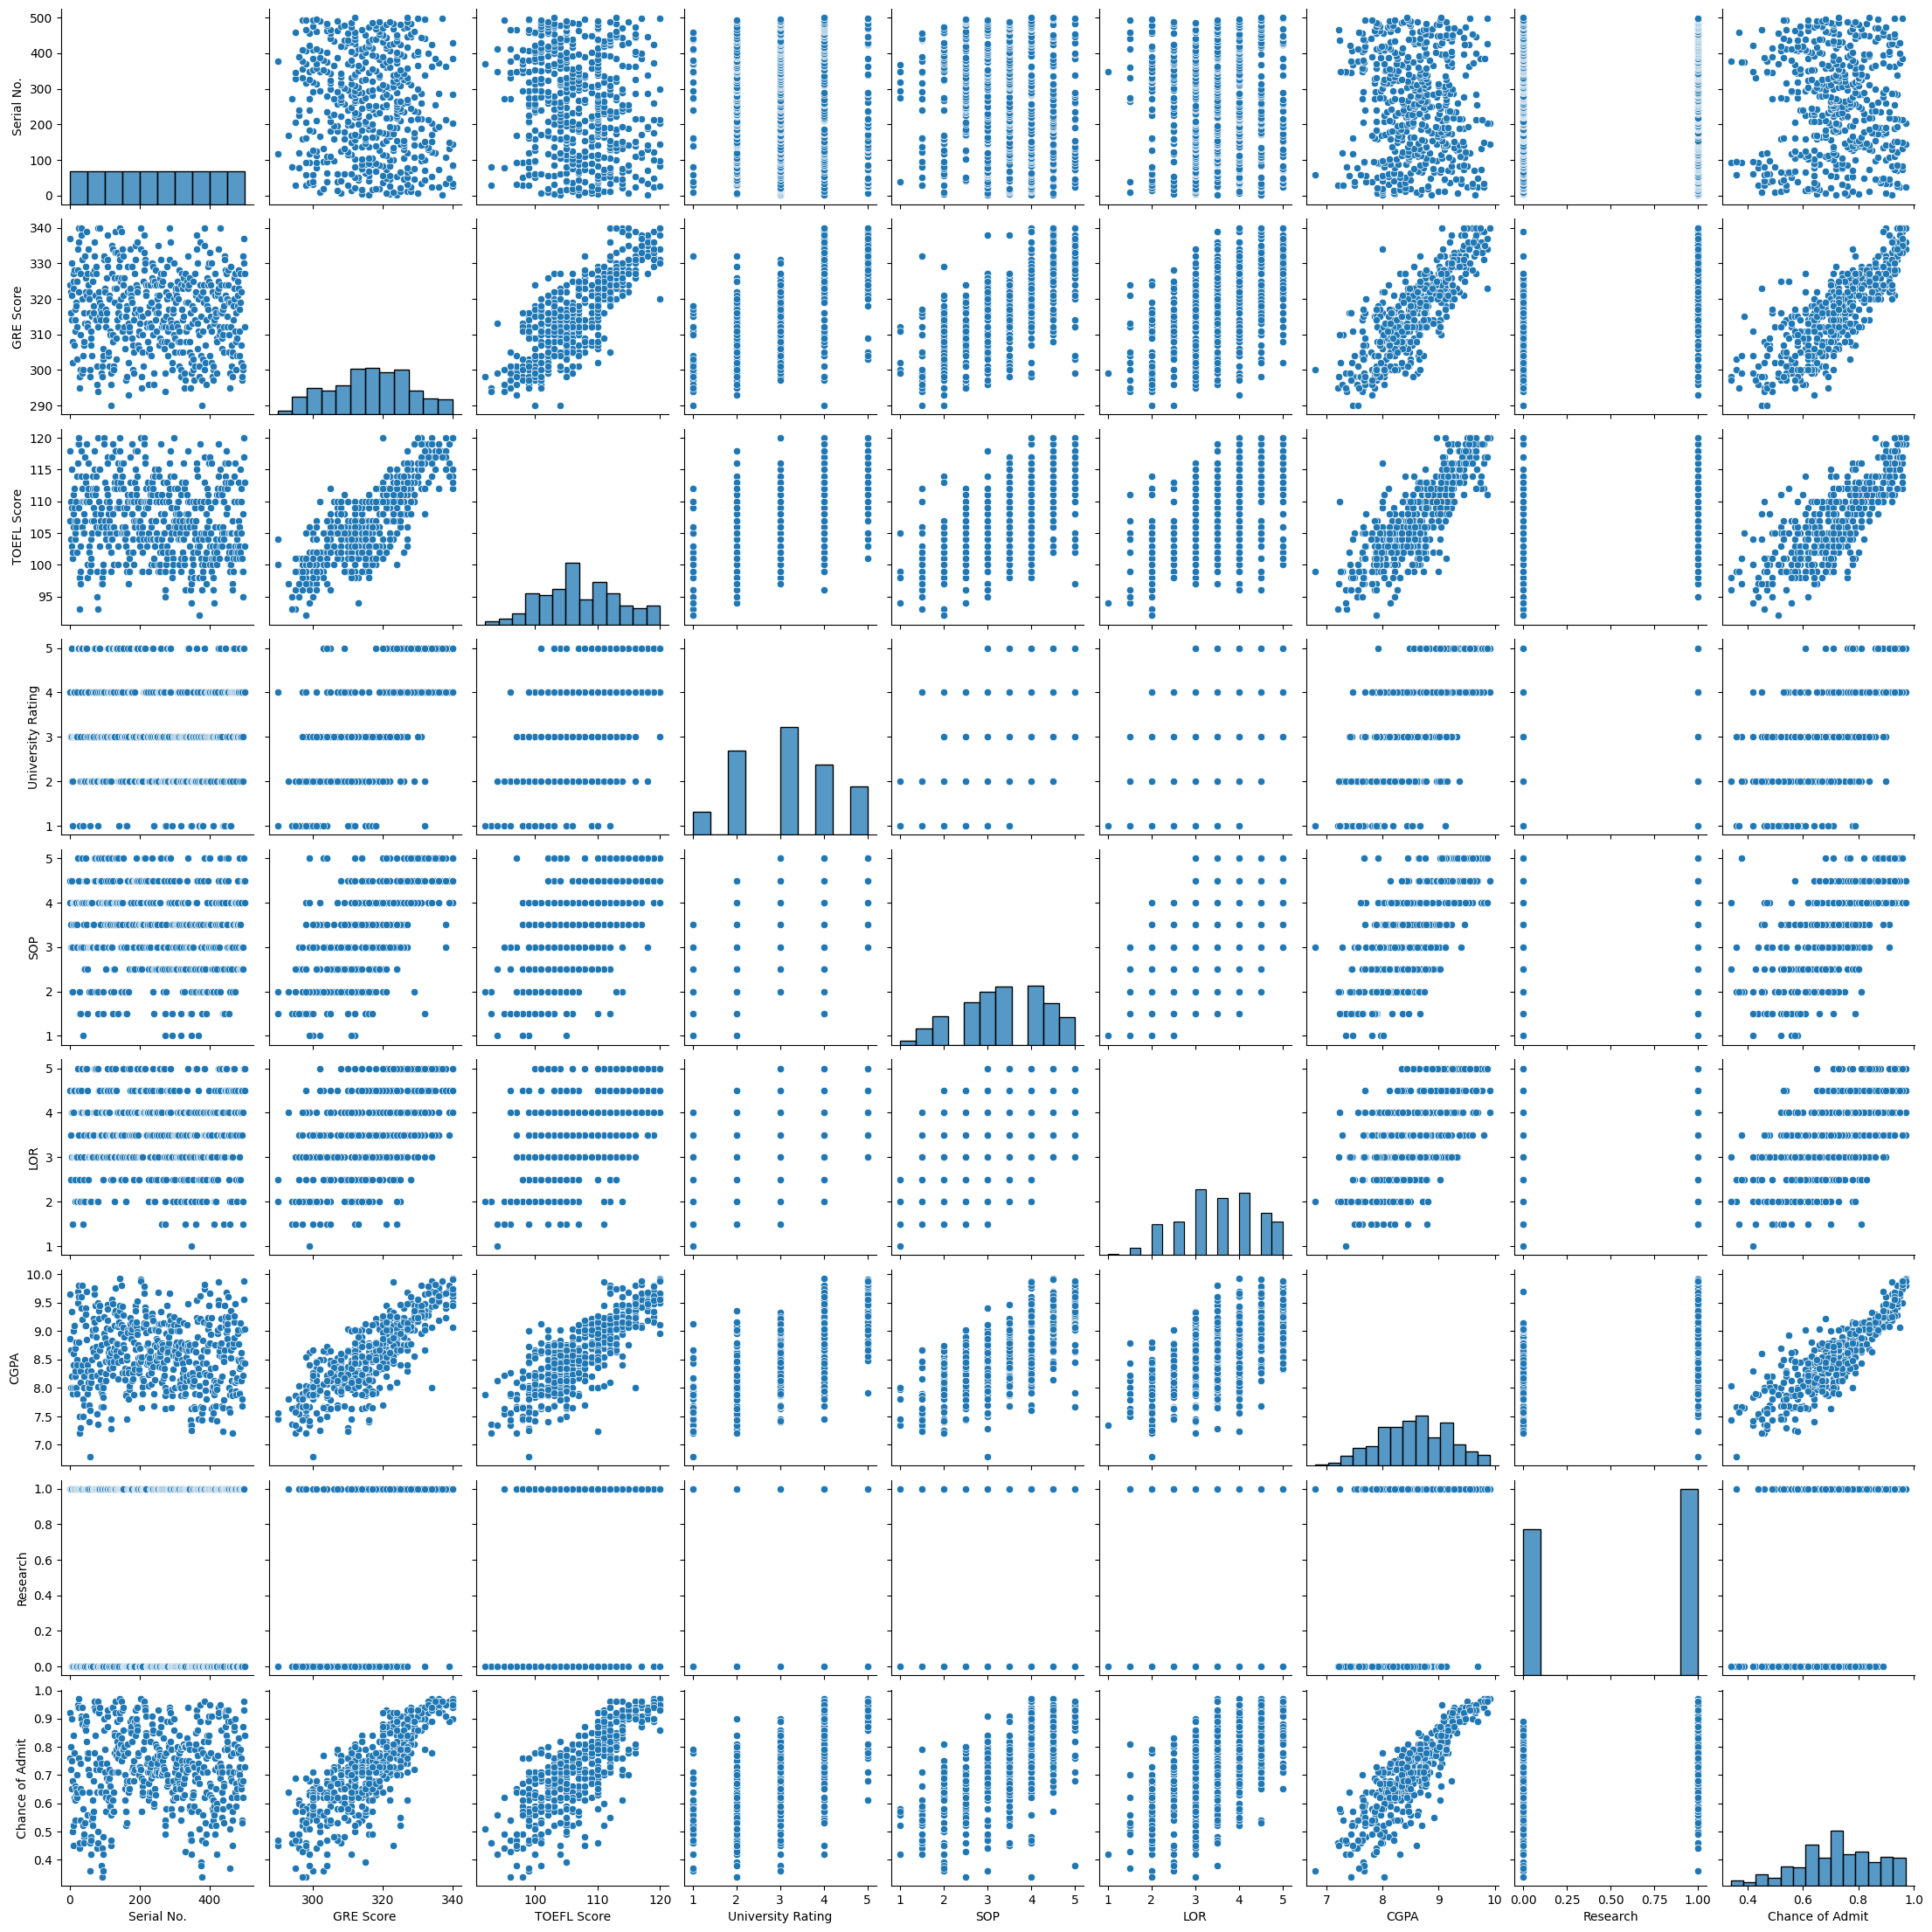

In [ ]:
df = pd.read_csv("graduate_prediction.csv")
# df.head()
print(df.sample(5))
print(df.columns)
print(df.describe())
print(df.isnull().sum())

print("Correlation Table")
print(df.corr())
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df)
plt.show()

Deciding which features to choose : Correlation with Chance of Admit
> 0.7: Strongly consider.

0.5 – 0.7: Consider.

< 0.1: Likely irrelevant.

Remove Irrelevant Features
Serial No. has near-zero correlation with target (0.0085). Drop it.


In [ ]:
df.drop(columns=['Serial No.'], inplace=True)

Step 3: Visualize Key Features vs Target

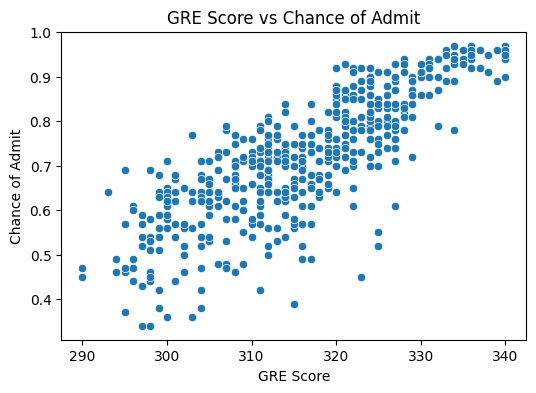

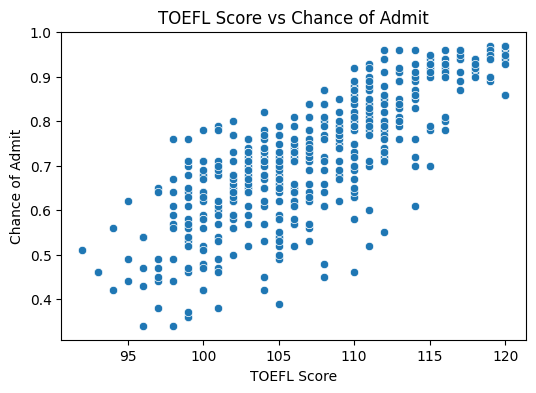

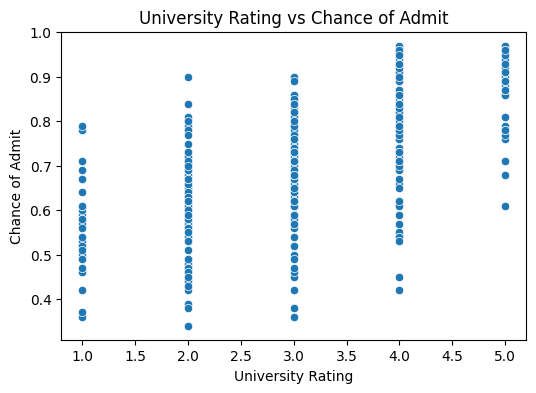

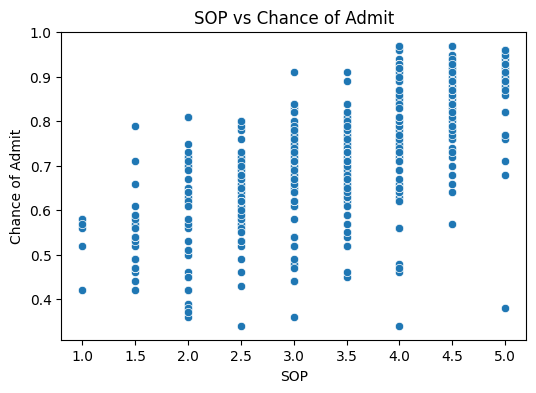

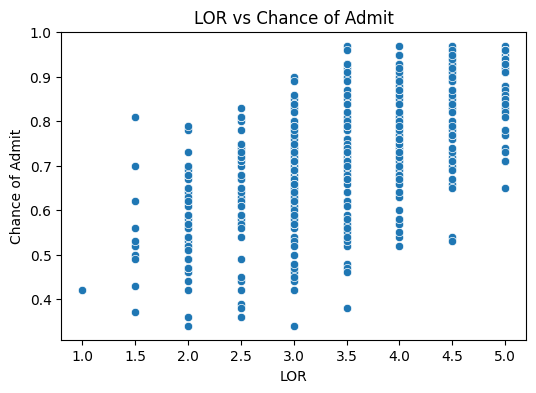

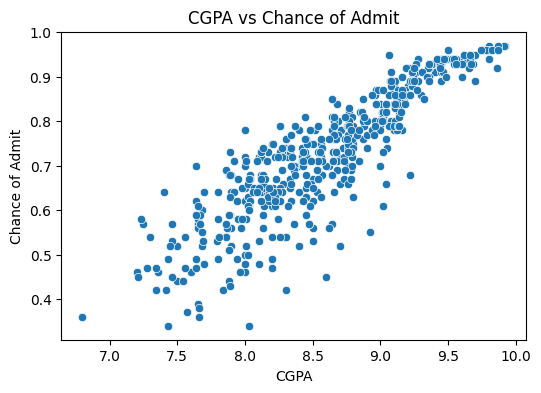

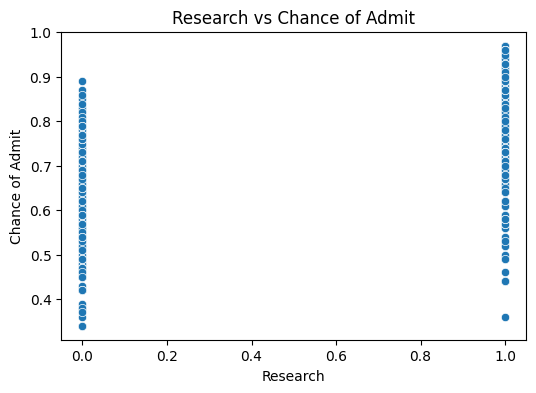

In [ ]:
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']
for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['Chance of Admit'])
    plt.title(f'{col} vs Chance of Admit')
    plt.show()

Step 4: Train-Test Split (80:20)

In [ ]:
# Define features (X) and target (y)
X = df[features]
y = df['Chance of Admit']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train Set Shape:", X_train.shape, y_train.shape)
print("Test Set Shape:", X_test.shape, y_test.shape)
print("Train Set Head:")
print(X_train.head())
print("Test Set Head:")
print(X_test.head())


Train Set Shape: (400, 7) (400,)
Test Set Shape: (100, 7) (100,)
Train Set Head:
     GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research
249        321          111                  3  3.5  4.0  8.83         1
433        316          111                  4  4.0  5.0  8.54         0
19         303          102                  3  3.5  3.0  8.50         0
322        314          107                  2  2.5  4.0  8.27         0
332        308          106                  3  3.5  2.5  8.21         1
Test Set Head:
     GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  Research
361        334          116                  4  4.0  3.5  9.54         1
73         314          108                  4  4.5  4.0  9.04         1
374        315          105                  2  2.0  2.5  7.65         0
155        312          109                  3  3.0  3.0  8.69         0
104        326          112                  3  3.5  3.0  9.05         1


Step 5: Linear Regression using scikit-learn

In [ ]:
# Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

# Evaluation
print("Linear Regression Results")
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Coefficients:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)


Linear Regression Results
Train MSE: 0.0035265554784557596
Test MSE: 0.003704655398788405
Train R2: 0.8210671369321553
Test R2: 0.8188432567829631
Coefficients: [0.00243444 0.00299587 0.0025688  0.00181369 0.01723798 0.11252708
 0.02402679]
Intercept: -1.4214470719016465


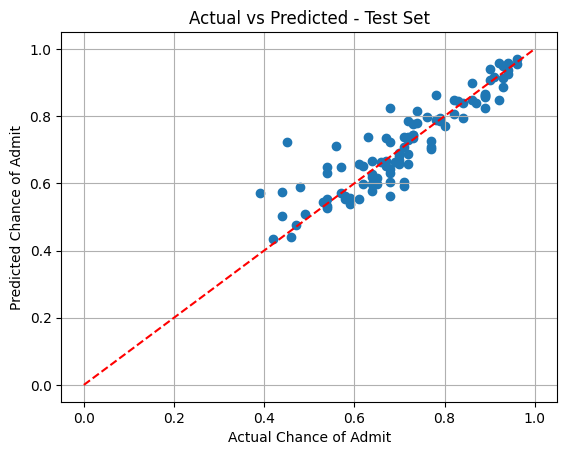

In [ ]:
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted - Test Set")
plt.grid(True)
plt.plot([0,1], [0,1], 'r--')  # Line y=x
plt.show()

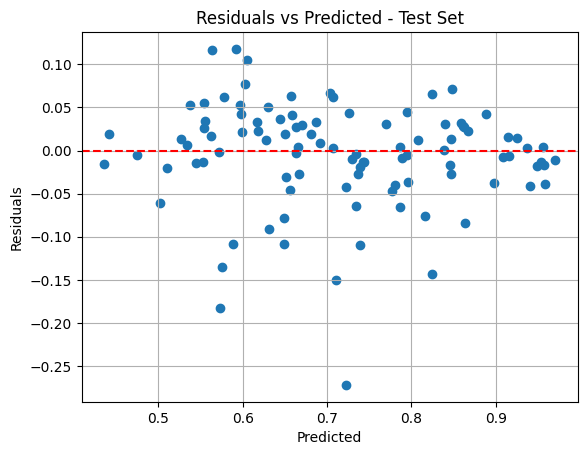

In [ ]:
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted - Test Set")
plt.grid(True)
plt.show()

Step 6: Implement Gradient Descent from Scratch (SSE Minimization)

Iteration   1: SSE = 217.6553
Iteration  11: SSE = 142.5840
Iteration  21: SSE = 95.2590
Iteration  31: SSE = 64.0489
Iteration  41: SSE = 43.2620
Iteration  51: SSE = 29.3876
Iteration  61: SSE = 20.1221
Iteration  71: SSE = 13.9331
Iteration  81: SSE = 9.7983
Iteration  91: SSE = 7.0352
Iteration 101: SSE = 5.1883
Iteration 111: SSE = 3.9531
Iteration 121: SSE = 3.1267
Iteration 131: SSE = 2.5734
Iteration 141: SSE = 2.2025
Iteration 151: SSE = 1.9535
Iteration 161: SSE = 1.7862
Iteration 171: SSE = 1.6734
Iteration 181: SSE = 1.5971
Iteration 191: SSE = 1.5453
Iteration 201: SSE = 1.5099
Iteration 211: SSE = 1.4856
Iteration 221: SSE = 1.4686
Iteration 231: SSE = 1.4568
Iteration 241: SSE = 1.4483
Iteration 250: SSE = 1.4426

Optimized Coefficients:
Weights: [0.03105576 0.02334775 0.00543691 0.0056719  0.01667419 0.05180357
 0.01222448]
Bias: 0.719536661378057

Train Set:
SSE: 1.4421
MSE: 0.0036
R2 : 0.8171

Test Set:
SSE: 0.3817
MSE: 0.0038
R2 : 0.8134


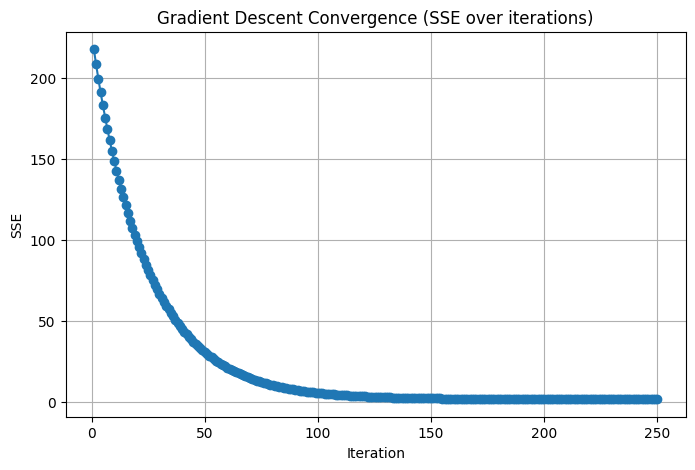

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ----------------
# 1) Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------
# 2) Initialize weights & bias
n_features = X_train_scaled.shape[1]
weights = np.zeros(n_features)
bias = 0

# Hyperparameters
learning_rate = 0.01
iterations = 250

# Store SSE at each iteration for plotting
sse_history = []

# ----------------
# 3) Gradient Descent Loop
for i in range(iterations):
    # Predict
    y_pred = np.dot(X_train_scaled, weights) + bias

    # Compute error
    errors = y_pred - y_train.values

    # Compute gradients
    grad_w = (2 / len(X_train_scaled)) * np.dot(X_train_scaled.T, errors)
    grad_b = (2 / len(X_train_scaled)) * np.sum(errors)

    # Update parameters
    weights -= learning_rate * grad_w
    bias -= learning_rate * grad_b

    # Compute SSE
    sse = np.sum(errors**2)
    sse_history.append(sse)

    if i % 10 == 0 or i == iterations-1:
        print(f"Iteration {i+1:3d}: SSE = {sse:.4f}")

print("\nOptimized Coefficients:")
print("Weights:", weights)
print("Bias:", bias)

# ----------------
# 4) Predictions with optimized model
y_train_opt_pred = np.dot(X_train_scaled, weights) + bias
y_test_opt_pred = np.dot(X_test_scaled, weights) + bias

# ----------------
# 5) Evaluation metrics
def print_metrics(y_true, y_pred, dataset_name):
    sse = np.sum((y_true - y_pred) ** 2)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Set:")
    print(f"SSE: {sse:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 : {r2:.4f}")

print_metrics(y_train, y_train_opt_pred, "Train")
print_metrics(y_test, y_test_opt_pred, "Test")

# ----------------
# 6) Plot loss curve (SSE vs. Iterations)
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), sse_history, marker='o')
plt.xlabel("Iteration")
plt.ylabel("SSE")
plt.title("Gradient Descent Convergence (SSE over iterations)")
plt.grid(True)
plt.show()

# # ----------------
# # 7) Correlation Heatmap
# plt.figure(figsize=(10, 8))
# corr_matrix = df.corr()
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title("Correlation Heatmap")
# plt.show()

# # ----------------
# # 8) Visualize Predicted vs Actual on Test Set
# plt.figure(figsize=(8, 6))
# plt.scatter(y_test, y_test_opt_pred, alpha=0.7, color='teal')
# plt.plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
# plt.xlabel("Actual Chance of Admit")
# plt.ylabel("Predicted Chance of Admit")
# plt.title("Actual vs Predicted on Test Set")
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
# Split before normalization to avoid data leakage
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compute mean & std from training data only
mean = X_train.mean()
std = X_train.std()

# Normalize both using train stats
X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std  # <- Key fix!

# Add intercept column (bias term)
X_train_norm.insert(0, 'Intercept', 1)
X_test_norm.insert(0, 'Intercept', 1)

# Convert to NumPy
X_train_np = X_train_norm.values
X_test_np = X_test_norm.values
y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

theta = np.zeros((X_train_np.shape[1], 1))
alpha = 0.01
iterations = 100

sse_history = []

for i in range(iterations):
    y_pred = X_train_np @ theta
    error = y_pred - y_train_np
    sse = np.sum(error ** 2)
    sse_history.append(sse)

    gradient = X_train_np.T @ error
    theta = theta - alpha * gradient / len(y_train_np)


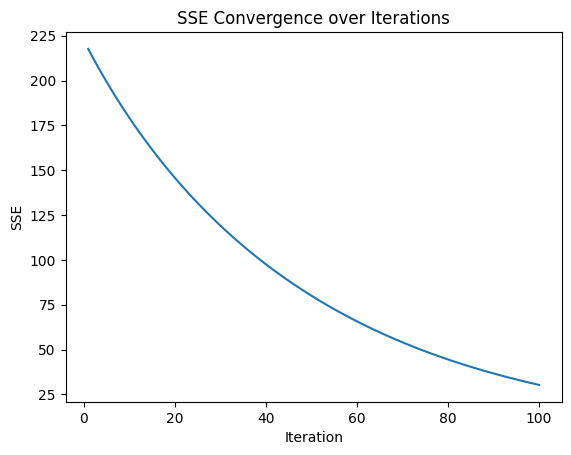

In [ ]:
plt.plot(range(1, iterations + 1), sse_history)
plt.xlabel('Iteration')
plt.ylabel('SSE')
plt.title('SSE Convergence over Iterations')
plt.show()


**2. Assignment**

Step-1:
Define input array X with angles from 60 deg to 360 deg converted in radians.
Step-2: Compute Y as Y=[Sin(X)+Cos(X)] + K^2
where K is a random number generated from normal distribution with 0.5 mean and
0.15 std dev.
Step-3: Create Linear Regression model with SSE as error, and different Non-Linear
Regression models of 3, 13th and 15th degree polynomials on data created in step-1
and step-2. (You may optimize the model for max. of 100 iterations using Gradient
Descent or you may change max. iterations as needed to get better result).
Step-4: Plot the created models for the power of 1, 3,13, 15, and print the SSE,
Coefficients for the plotted models, and print the prediction of test set on 15th Deg.
Polynomial model.
Step-5: Add the L2 regularization to the nonlinear regression model with 15th degree
polynomial created in Step 3. (Optimize for Max. of 50 Iterations and lambda values
[1e-10 and 1e-5])
Step-6: Plot the Ridge (L2) regression models for lambda values [1e-10 and 1e-5] and
print the SSE, Coefficients for the plotted models, and print the prediction of test set
on 15th Deg. Polynomial model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.model_selection import train_test_split


Step 1: Define input X

In [ ]:
X = np.linspace(60, 360, 300).reshape(-1, 1)  # 60° to 360° in degrees
X_rad = np.deg2rad(X)
print(X.shape)
# print(X_rad)

(300, 1)


Step 2: Compute Y as Y=[Sin(X)+Cos(X)] + K^2
where K is a random number generated from normal distribution with 0.5 mean and
0.15 std dev.

Total samples: 300


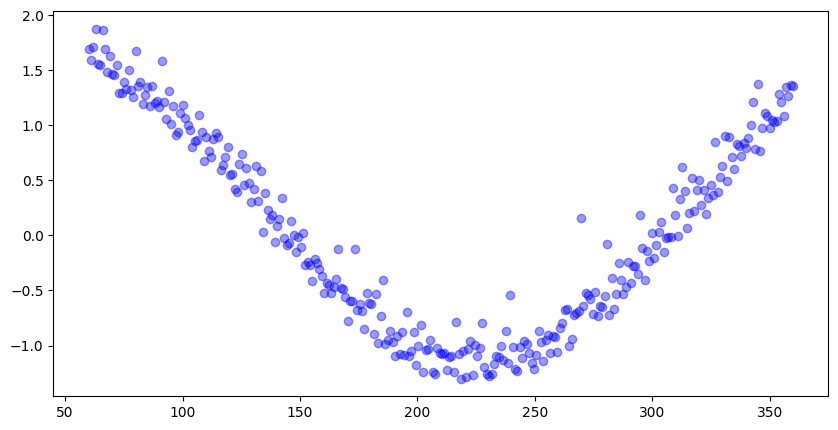

In [ ]:
np.random.seed(42)
k = np.random.normal(loc=0.5, scale=0.15, size=X.shape)
# print(k)
Y = (np.sin(X_rad) + np.cos(X_rad)) + k**2
# print(Y)
print("Total samples:", len(Y))

plt.figure(figsize=(10,5))
plt.scatter(X, Y, color='blue', alpha=0.4, label='Data')



Step-3: Create Linear Regression model with SSE as error, and different Non-Linear
Regression models of 3, 13th and 15th degree polynomials on data created in step-1
and step-2. (You may optimize the model for max. of 100 iterations using Gradient
Descent or you may change max. iterations as needed to get better result).

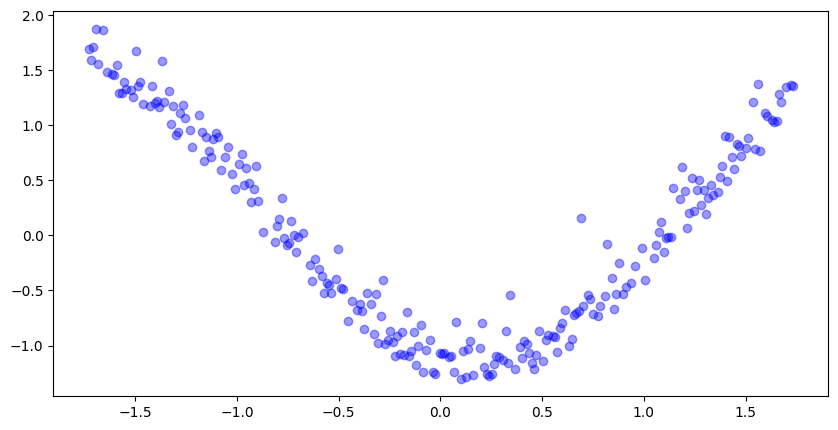

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_rad, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
plt.figure(figsize=(10,5))
plt.scatter(X_train_scaled, y_train, color='blue', alpha=0.4, label='Data')



In [ ]:
# === 2) Gradient Descent implementation ===
def gradient_descent(X_poly, y, learning_rate=1e-5, iterations=500, reg_lambda=0.0):
    n_samples, n_features = X_poly.shape
    weights = np.zeros((n_features, 1))
    for _ in range(iterations):
        y_pred = X_poly @ weights
        errors = y_pred - y
        grad = (2 / n_samples) * (X_poly.T @ errors) + 2 * reg_lambda * weights
        weights -= learning_rate * grad
    return weights

In [ ]:
# === 3) Evaluation & Plotting ===
def evaluate(X, y, poly, weights, label):
    X_poly = poly.transform(X)
    y_pred = X_poly @ weights
    sse = np.sum((y - y_pred)**2)
    print(f"{label}: SSE={sse:.4f}\n  Coefficients={weights.flatten()}\n")
    return y_pred, sse


In [ ]:
def plot_fit(X_plot, y_pred, label, color):
    idx = X_plot[:,0].argsort()
    plt.plot(scaler.inverse_transform(X_plot[idx]), y_pred[idx], label=label, color=color)



========== Degree 1 ==========
Degree 1 - GD: SSE=196.2254
  Coefficients=[ 3.66872931e-05 -2.41468613e-03]

Degree 1 - Ridge: SSE=50553.2398
  Coefficients=[ 0.00368737 -0.24269535]

Degree 1 - SGDRegressor: SSE=182.6679
  Coefficients=[ 0.00161235 -0.20664235]



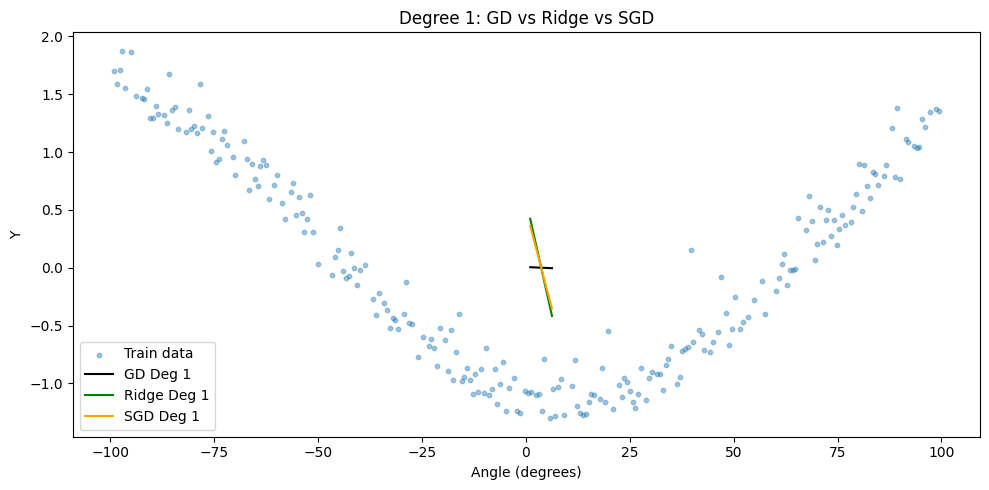

Predictions on Test Set (Degree 1 - Ridge):
[-0.1472868  -0.32436612 -0.00393688  0.39800506 -0.23161029 -0.21193481
 -0.12761132  0.11692678  0.40924819 -0.06858489 -0.24285342  0.26308749
 -0.18944855  0.29681688 -0.08826037 -0.19788089 -0.38901413 -0.16977307
  0.00730625 -0.04047706  0.20406105  0.10568365 -0.27658281 -0.2793936
  0.13098069  0.30524923 -0.36652786 -0.40587882 -0.01799079 -0.2456642
  0.3755188  -0.03766627  0.33054627  0.35584332 -0.1810162   0.08881895
  0.40362663  0.17033165  0.2940061   0.21811496  0.1618993   0.20968261
 -0.38058178  0.25465514  0.20687183  0.24622279 -0.23442107 -0.22036716
  0.11130521 -0.22598872 -0.0826388   0.01854938 -0.24847499  0.2124934
 -0.41150039 -0.35809551  0.15065617  0.16471009 -0.11636819  0.35303254]


========== Degree 3 ==========
Degree 3 - GD: SSE=192.9092
  Coefficients=[-9.13980077e-07 -2.38285246e-03  7.54816940e-03 -3.49711550e-03]

Degree 3 - Ridge: SSE=91614.5819
  Coefficients=[-0.92090702 -0.50578053  0.92459665 

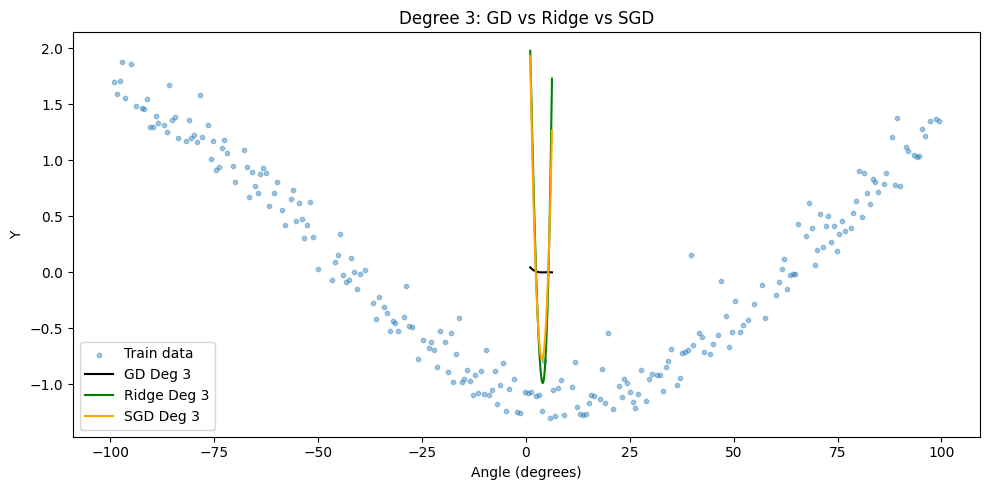

Predictions on Test Set (Degree 3 - Ridge):
[-0.84327292  0.43842667 -0.93587914  1.72743417 -0.41168439 -0.54002439
 -0.90124741 -0.4981692   1.8379875  -0.98574973 -0.33046177  0.50109748
 -0.6657      0.78647759 -0.97202802 -0.62115644  1.28811695 -0.75780617
 -0.91316011 -0.98146555  0.04633393 -0.55567002 -0.05140223 -0.02570179
 -0.42193225  0.86036171  0.96732953  1.54691948 -0.95860566 -0.3092467
  1.50933114 -0.97953558  1.0875313   1.32221998 -0.70718585 -0.63590645
  1.78259458 -0.18405171  0.76206546  0.14895809 -0.23793784  0.08693427
  1.16459957  0.43247173  0.06655833  0.36500576 -0.39192172 -0.48715076
 -0.52731348 -0.45013177 -0.97738697 -0.88650001 -0.28766518  0.10746044
  1.63671288  0.85406416 -0.30735906 -0.22014693 -0.92751792  1.2958024 ]


========== Degree 13 ==========
Degree 13 - GD: SSE=114.5879
  Coefficients=[-0.0021664  -0.00168901  0.00209607 -0.00180393  0.00422289 -0.00234573
  0.00707474 -0.00323665  0.01062054 -0.00424059  0.01190954 -0.00412397
 -

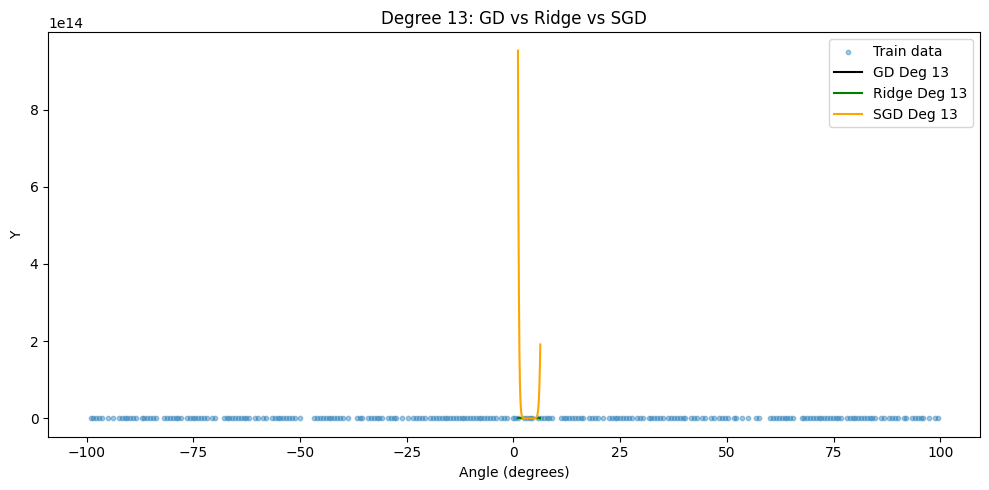

Predictions on Test Set (Degree 13 - Ridge):
[-0.81588084  0.53674756 -1.08613269  1.53528013 -0.23172382 -0.38618198
 -0.91297624 -0.56161802  1.62245962 -1.08999562 -0.1407873   0.72531257
 -0.55183498  0.97864435 -1.05043876 -0.49135836  1.10273281 -0.68372294
 -1.06523325 -1.11310187  0.1809466  -0.63775724  0.13777226  0.16115753
 -0.45903379  1.03174634  0.89986559  1.25856612 -1.10398313 -0.11783772
  1.38791129 -1.11328759  1.16849878  1.28700455 -0.61004041 -0.74173932
  1.57811488 -0.13242332  0.9600107   0.31514101 -0.20675382  0.23459637
  1.02588073  0.65300011  0.20775486  0.57796273 -0.20913584 -0.32086299
 -0.6003591  -0.27655438 -1.06372718 -1.03851107 -0.09481812  0.26145344
  1.31092082  0.82557457 -0.30241863 -0.18220819 -0.96012336  1.27378698]


========== Degree 15 ==========
Degree 15 - GD: SSE=nan
  Coefficients=[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]

Degree 15 - Ridge: SSE=92740.2560
  Coefficients=[-1.07260746 -0.47802777  1.3524671

/tmp/ipython-input-86-3290724186.py:8: RuntimeWarning: overflow encountered in matmul
  grad = (2 / n_samples) * (X_poly.T @ errors) + 2 * reg_lambda * weights
/tmp/ipython-input-86-3290724186.py:6: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_poly @ weights


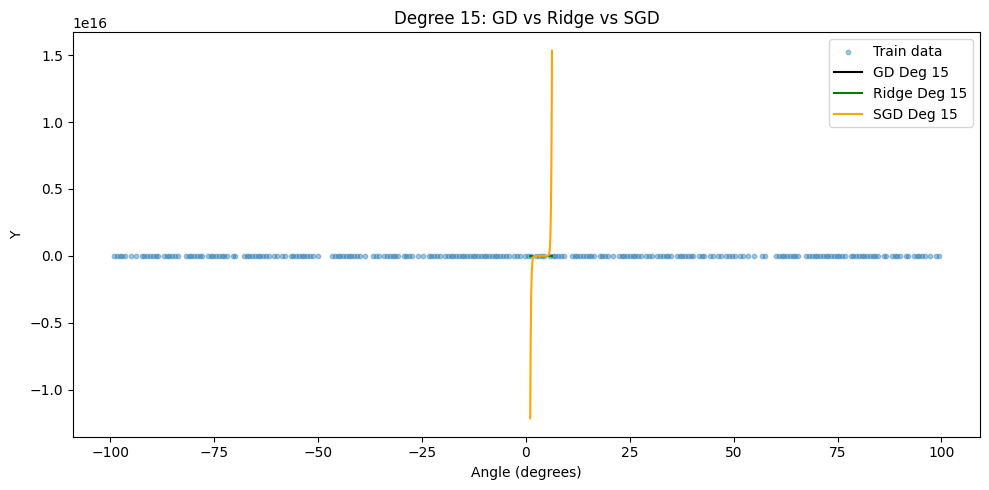

Predictions on Test Set (Degree 15 - Ridge):
[-0.81595652  0.53451234 -1.08628722  1.53745337 -0.2274065  -0.3810439
 -0.91441258 -0.56040302  1.62747851 -1.0918289  -0.13784325  0.72403729
 -0.54781751  0.98046411 -1.05261173 -0.48672521  1.09815065 -0.68161212
 -1.06517904 -1.11416414  0.17962745 -0.63659207  0.13422898  0.15710702
 -0.45784267  1.03416371  0.90814124  1.24763848 -1.104448   -0.11533243
  1.38478558 -1.11427034  1.17059865  1.28544936 -0.60678941 -0.74071435
  1.58216671 -0.13211744  0.96158609  0.31321789 -0.20614178  0.23301312
  1.02801082  0.65120595  0.20630085  0.5758408  -0.20510125 -0.31583393
 -0.59916301 -0.27179752 -1.06583458 -1.0382797  -0.09278515  0.25974796
  1.30845282  0.83401409 -0.30149853 -0.18169129 -0.9620264   1.27268791]



In [ ]:
degrees = [1, 3, 13, 15]

for deg in degrees:
    print(f"\n========== Degree {deg} ==========")
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # 1) Gradient Descent
    w_gd = gradient_descent(X_train_poly, y_train, learning_rate=1e-5, iterations=500, reg_lambda=0.1)
    y_pred_gd, sse_gd = evaluate(X_train_scaled, y_train, poly, w_gd, f"Degree {deg} - GD")

    # 2) Ridge Regression
    ridge = Ridge(alpha=0.1, fit_intercept=False)
    ridge.fit(X_train_poly, y_train)
    y_pred_ridge = ridge.predict(X_train_poly)
    sse_ridge = np.sum((y_train - y_pred_ridge)**2)
    print(f"Degree {deg} - Ridge: SSE={sse_ridge:.4f}\n  Coefficients={ridge.coef_}\n")

    # 3) SGDRegressor
    sgd = SGDRegressor(alpha=0.1, penalty='l2', max_iter=1000, learning_rate='constant', eta0=1e-3)
    sgd.fit(X_train_poly, y_train.ravel())
    y_pred_sgd = sgd.predict(X_train_poly)
    sse_sgd = np.sum((y_train.ravel() - y_pred_sgd)**2)
    print(f"Degree {deg} - SGDRegressor: SSE={sse_sgd:.4f}\n  Coefficients={sgd.coef_}\n")

    # Plot comparison
    plt.figure(figsize=(10,5))
    plt.scatter(np.degrees(X_train_scaled), y_train, s=10, alpha=0.4, label='Train data')
    plot_fit(X_train_scaled, y_pred_gd, f"GD Deg {deg}", 'black')
    plot_fit(X_train_scaled, y_pred_ridge, f"Ridge Deg {deg}", 'green')
    plot_fit(X_train_scaled, y_pred_sgd, f"SGD Deg {deg}", 'orange')
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Y")
    plt.legend()
    plt.title(f"Degree {deg}: GD vs Ridge vs SGD")
    plt.tight_layout()
    plt.show()

    # Test predictions with best (ridge)
    y_test_pred = ridge.predict(X_test_poly)
    print(f"Predictions on Test Set (Degree {deg} - Ridge):\n{y_test_pred.flatten()}\n")

Fourier Fit: SSE=5.9104, Coefficients=[[ 3.31084875 -0.66352093 -5.89272984  0.45535663  2.57329141 -0.5322261
  -1.49529764  0.31982029  0.48285338 -0.09004769 -0.07253603]]



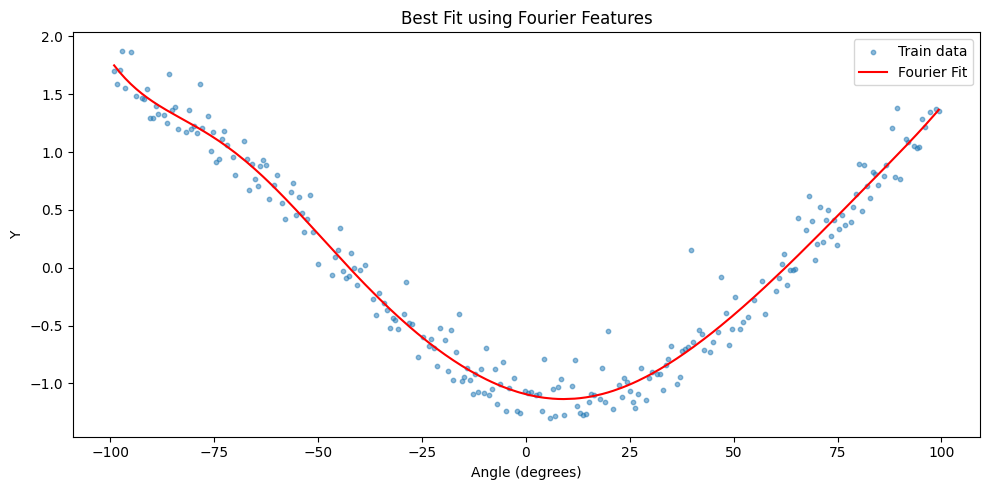

Predictions on Test Set (Fourier Fit):
[-0.80084878  0.53793553 -1.10835681  1.52493299 -0.23240121 -0.3805461
 -0.90227964 -0.5489692   1.61202865 -1.10315982 -0.14449981  0.71876592
 -0.53957965  0.97315276 -1.05539566 -0.48134297  1.10111349 -0.66817139
 -1.08546111 -1.13446986  0.18671943 -0.62699987  0.13057002  0.15411073
 -0.44501269  1.02798239  0.9026657   1.25630755 -1.12727564 -0.12219245
  1.39045846 -1.1351418   1.17194824  1.29463075 -0.59599601 -0.73505889
  1.56634798 -0.12014412  0.95406725  0.31751324 -0.19347116  0.2390287
  1.02594407  0.64752112  0.21286231  0.5739337  -0.21063254 -0.31799975
 -0.58856914 -0.27550302 -1.07113383 -1.05588984 -0.09975987  0.26520322
  1.3101398   0.8293861  -0.28830242 -0.16922584 -0.95324432  1.28142079]


In [ ]:
from sklearn.linear_model import LinearRegression

def fourier_features(X, n_harmonics=5):
    feats = [np.ones_like(X)]  # bias term
    for k in range(1, n_harmonics+1):
        feats.append(np.sin(k * X))
        feats.append(np.cos(k * X))
    return np.hstack(feats)

# === Prepare Fourier features ===
X_train_fourier = fourier_features(X_train_scaled, n_harmonics=5)
X_test_fourier = fourier_features(X_test_scaled, n_harmonics=5)

# === Train linear model on Fourier features ===
model_fourier = LinearRegression(fit_intercept=False)
model_fourier.fit(X_train_fourier, y_train)
y_train_pred = model_fourier.predict(X_train_fourier)
sse_train = np.sum((y_train - y_train_pred)**2)
print(f"Fourier Fit: SSE={sse_train:.4f}, Coefficients={model_fourier.coef_}\n")

# === Plot ===
plt.figure(figsize=(10,5))
plt.scatter(np.degrees(X_train_scaled), y_train, s=10, alpha=0.5, label='Train data')
idx = X_train_scaled[:,0].argsort()
plt.plot(np.degrees(X_train_scaled[idx]), y_train_pred[idx], label="Fourier Fit", color='red')
plt.xlabel("Angle (degrees)")
plt.ylabel("Y")
plt.legend()
plt.title("Best Fit using Fourier Features")
plt.tight_layout()
plt.show()

# === Predictions on Test Set ===
y_test_pred = model_fourier.predict(X_test_fourier)
print("Predictions on Test Set (Fourier Fit):")
print(y_test_pred.flatten())
